In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("cars_clus.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=117, step=1)
All columns are
0 manufact
1 model
2 sales
3 resale
4 type
5 price
6 engine_s
7 horsepow
8 wheelbas
9 width
10 length
11 curb_wgt
12 fuel_cap
13 mpg
14 lnsales
15 partition


In [4]:
df.shape

(117, 16)

In [5]:
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0
1,Acura,TL,39.384,19.875,0,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0
2,Acura,RL,8.588,29.725,0,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0
3,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0
4,Audi,A6,18.780,23.555,0,33.95,2.8,200,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0


In [7]:
df.sample(n=10)

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
70,Mitsubishi,Montero Sport,39.348,13.880,1,22.527,3.0,173,107.3,66.7,178.3,3.510,19.5,20.0,3.672,0
9,Buick,Regal,39.350,13.740,0,25.300,3.8,240,109.0,72.7,196.2,3.543,17.5,23.0,3.672,0
55,Infiniti,I30,23.713,19.690,0,29.465,3.0,227,108.3,70.2,193.7,3.342,18.5,25.0,3.166,0
76,Mercury,Villager,20.380,14.795,1,22.510,3.3,170,112.2,74.9,194.7,3.944,20.0,21.0,3.015,0
35,Dodge,Dakota,111.313,11.260,1,16.980,2.5,120,131.0,71.5,215.0,3.557,22.0,19.0,4.712,0
29,Dodge,Avenger,4.734,12.545,0,19.045,2.5,163,103.7,69.1,190.2,2.879,15.9,24.0,1.555,0
4,Audi,A6,18.780,23.555,0,33.950,2.8,200,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0
78,Mercedes-Benz,E-Class,27.602,41.450,0,49.900,3.2,221,111.5,70.8,189.4,3.823,21.1,25.0,3.318,0
45,Ford,Ranger,220.650,7.850,1,12.050,2.5,119,117.5,69.4,200.7,3.086,20.0,23.0,5.397,0
11,Buick,LeSabre,83.257,13.360,0,27.885,3.8,205,112.2,73.5,200.0,3.591,17.5,25.0,4.422,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   117 non-null    object 
 1   model      117 non-null    object 
 2   sales      117 non-null    float64
 3   resale     117 non-null    float64
 4   type       117 non-null    int64  
 5   price      117 non-null    float64
 6   engine_s   117 non-null    float64
 7   horsepow   117 non-null    int64  
 8   wheelbas   117 non-null    float64
 9   width      117 non-null    float64
 10  length     117 non-null    float64
 11  curb_wgt   117 non-null    float64
 12  fuel_cap   117 non-null    float64
 13  mpg        117 non-null    float64
 14  lnsales    117 non-null    float64
 15  partition  117 non-null    int64  
dtypes: float64(11), int64(3), object(2)
memory usage: 14.8+ KB


In [9]:
df.isnull()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
113,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
114,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
115,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
print(df.isnull().sum())
print("The data seems to not have any null values")

manufact     0
model        0
sales        0
resale       0
type         0
price        0
engine_s     0
horsepow     0
wheelbas     0
width        0
length       0
curb_wgt     0
fuel_cap     0
mpg          0
lnsales      0
partition    0
dtype: int64
The data seems to not have any null values


In [11]:
df.describe()

,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.0
mean,59.112316,18.031538,0.247863,25.969487,3.048718,181.282051,107.326496,71.189744,187.717949,3.324051,17.812821,24.117949,3.401179,0.0
std,75.058933,11.605632,0.433629,14.149699,1.055169,58.591786,8.050588,3.530151,13.849926,0.597177,3.794609,4.404164,1.337862,0.0
min,0.110000,5.160000,0.000000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,-2.207000,0.0
25%,16.767000,11.240000,0.000000,16.980000,2.200000,140.000000,102.400000,68.500000,177.500000,2.911000,15.300000,22.000000,2.819000,0.0
50%,32.299000,14.010000,0.000000,21.665000,3.000000,175.000000,107.000000,70.400000,187.800000,3.340000,17.200000,24.000000,3.475000,0.0
75%,76.029000,19.875000,0.000000,29.465000,3.800000,210.000000,111.600000,73.600000,196.500000,3.823000,19.800000,26.000000,4.331000,0.0
max,540.561000,67.550000,1.000000,82.600000,8.000000,450.000000,138.700000,79.300000,224.500000,5.115000,32.000000,45.000000,6.293000,0.0


In [19]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)

duplicates("manufact")
print()
duplicates("model")
print()
print("This means that model has no duplicate values, all are different so it's better to drop it")
print(df.columns)

         manufact  Count
0            Ford     10
1           Dodge      9
2       Chevrolet      8
3          Toyota      8
4      Mitsubishi      7
5         Mercury      6
6        Chrysler      5
7           Honda      5
8         Pontiac      5
9          Nissan      5
10     Volkswagen      5
11  Mercedes-Benz      4
12     Oldsmobile      4
13          Buick      4
14         Saturn      3
15        Porsche      3
16       Plymouth      3
17          Acura      3
18           Audi      3
19           Jeep      3
20        Hyundai      3
21       Cadillac      3
22          Lexus      3
23        Lincoln      2
24            BMW      2

  model  Count
0  Neon      2

This means that model has no duplicate values, all are different so it's better to drop it
Index(['manufact', 'model', 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales', 'partition'],
      dtype='object')


In [24]:
# Lets drop model, lnsales and partition
df = df.drop(['lnsales', 'partition','model'],axis=1)
print(df.columns)

KeyError: "['lnsales', 'partition', 'model'] not found in axis"

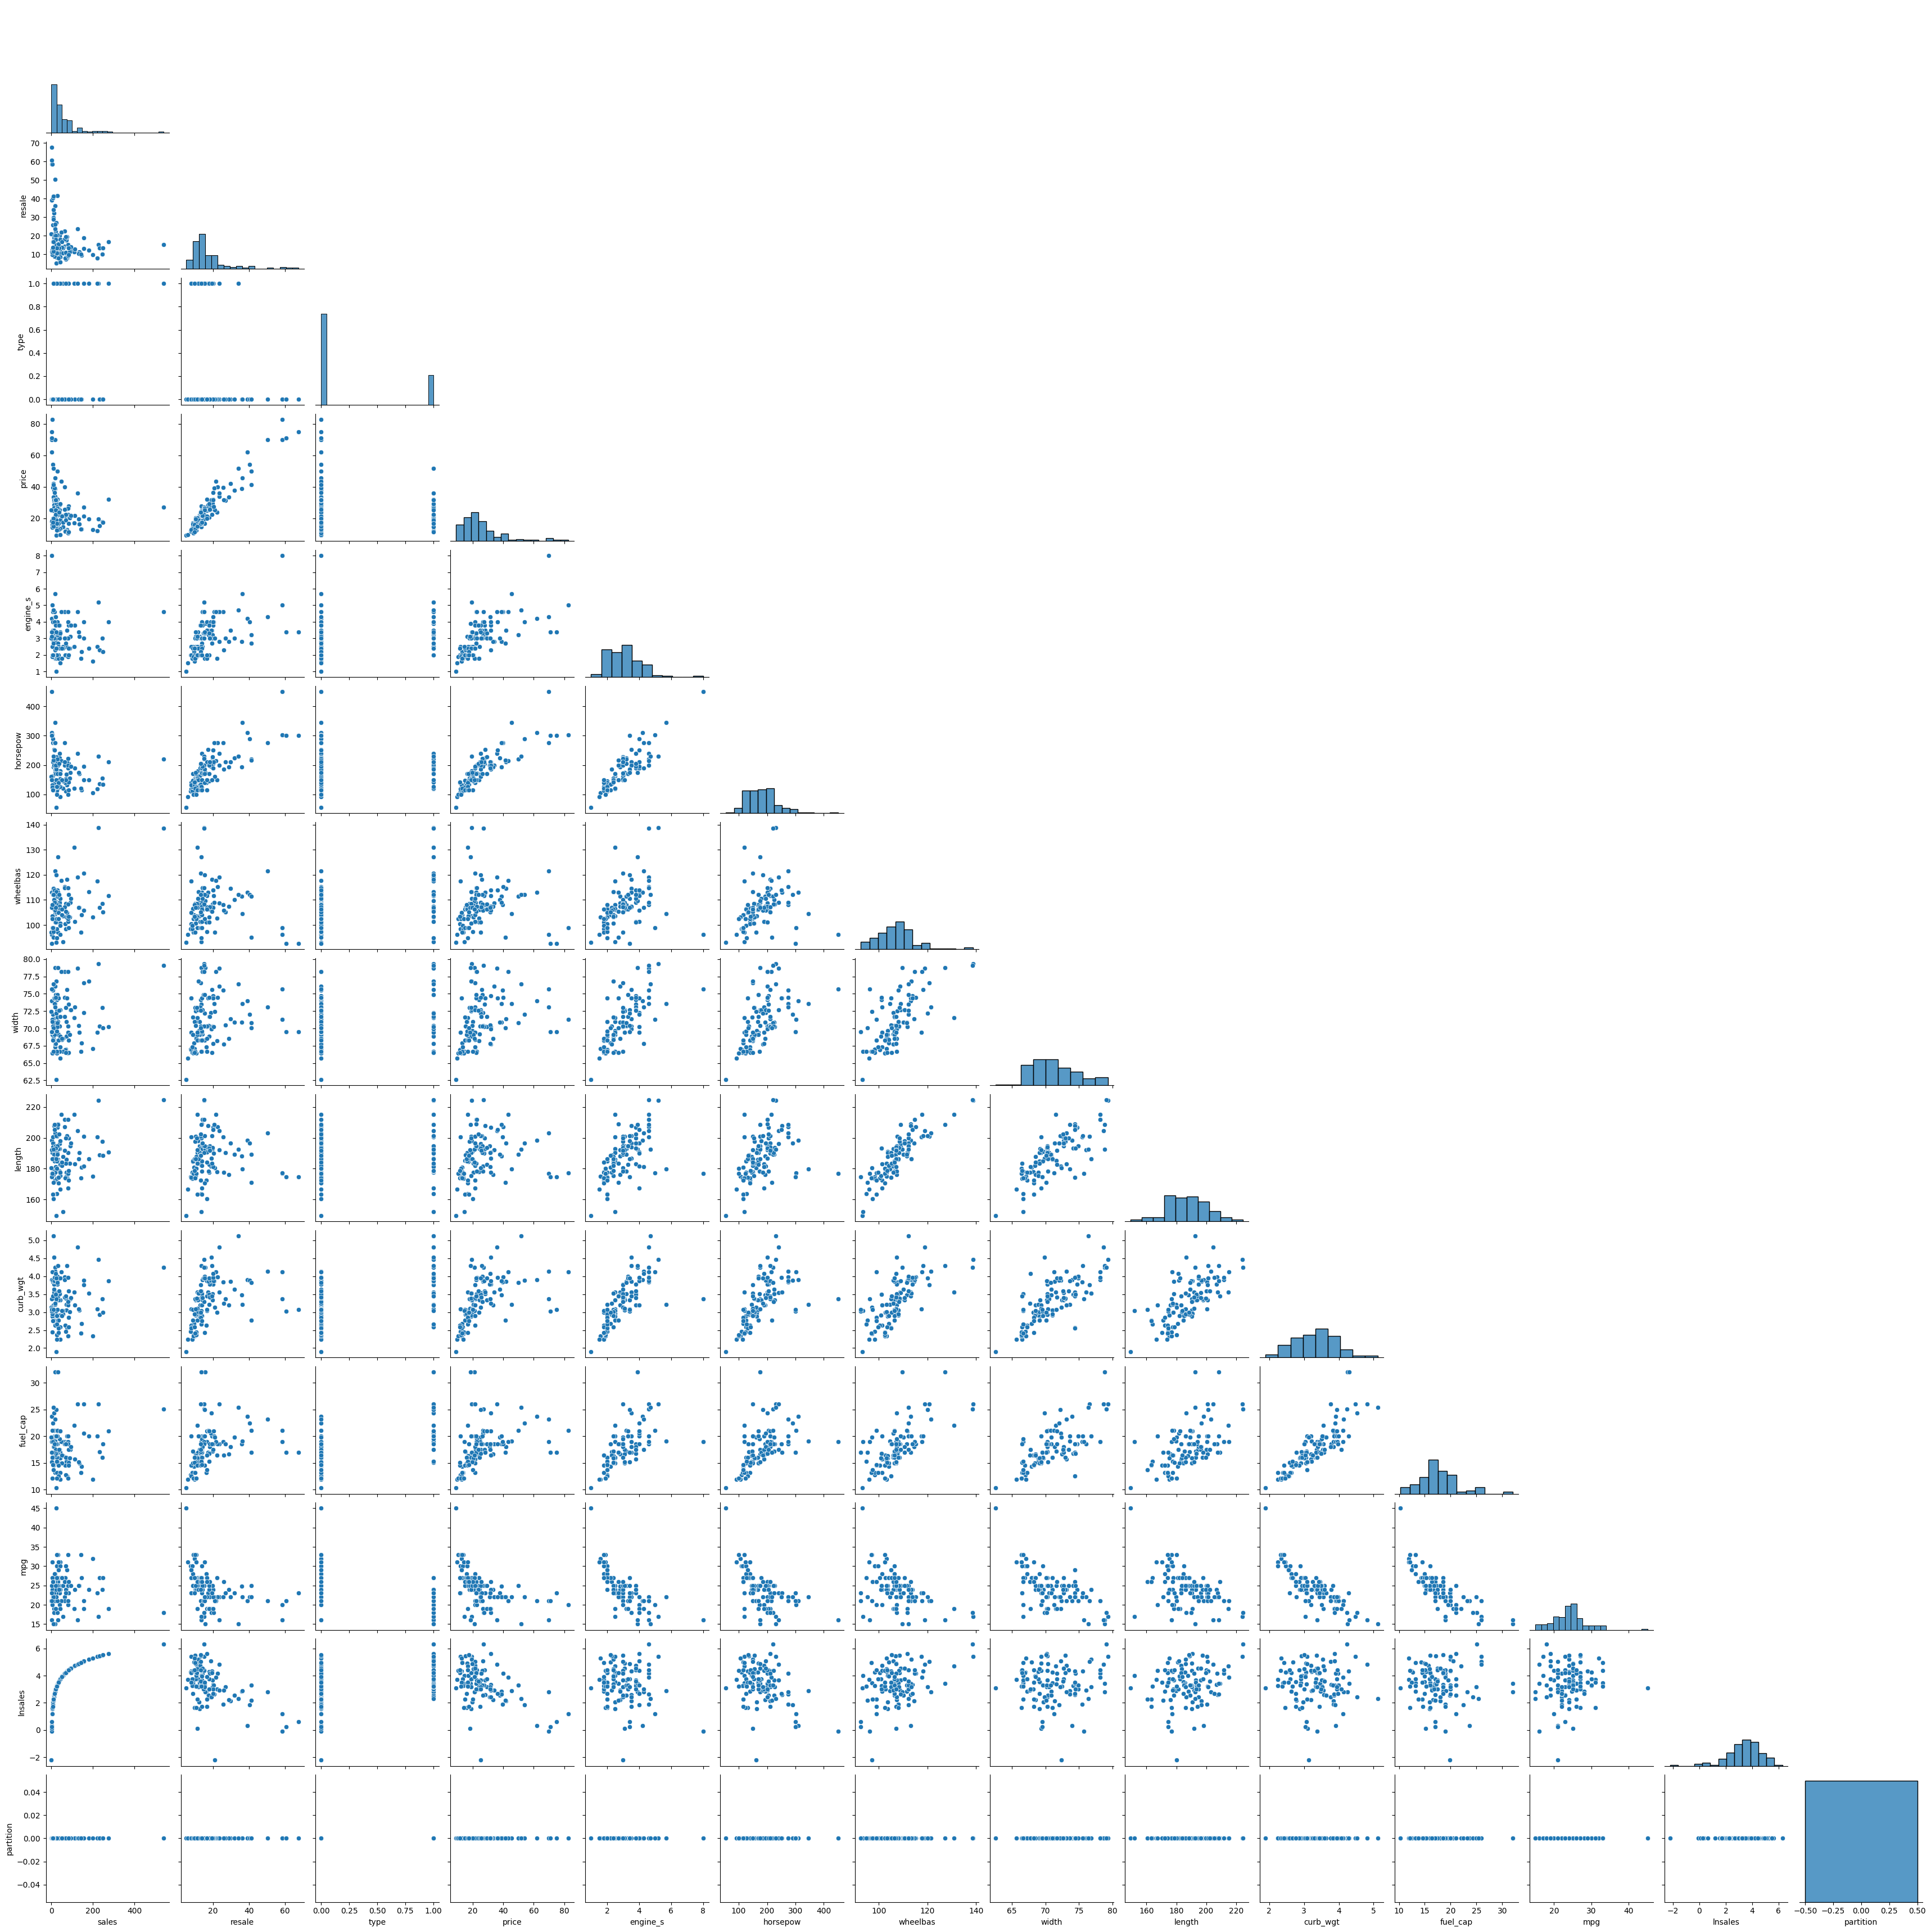

In [18]:
grid = sns.pairplot(df,corner=True)

In [ ]:


grid.savefig('carpairplot.png', dpi=300, bbox_inches='tight')

